Dzisiaj próg decyzyjny (Threshold Tuning) - zmienię czułość modelu
Domyślnie las losowy działa w taki sposób: jeśli prawdopodobieństwo toksyczności >50% zwraca wynik 1, a jeśli <50% zwraca wynik 0. Jest to dosyć absurdalne bo w przypadku leków. Model zatwierdzi jako bezpieczny lek który miał prawdopodobieństwo toksyczności na poziomie 49%, doprowadzić to może to negatywnych skutków. Zmienię dzisiaj próg z 50% na 30% i zobacze jak zachowuję się model. Korzystać będe z pasy ClinTox tak jak w poprzednich dniach :)
Informacje na temat użytych narzędzi można zobaczyć w Day11 tam opisałem do czego one slużą.

In [2]:
import pandas as pd #Tabele
import numpy as np #Matematyka
import matplotlib.pyplot as plt #Rysowanie wykresów
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.ensemble import RandomForestClassifier #Algorytm sztucznej inteligencji
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Pobieranie bazy danych ClinTox...")
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/clintox.csv.gz"
df = pd.read_csv(url)

Pobieranie bazy danych ClinTox...


Weryfikacja chemiczna i wektoryzacja

In [8]:
#TO WŁĄSNIE TUTAJ POPEŁNIŁEM BŁĄD (CZYTAJ MARKDOWN NIŻEJ)
czyste_smiles = []
toksycznosc = []
X_lista = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

for index, row in df.iterrows():
    sml = row['smiles']
    tox_label = row['FDA_APPROVED'] #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    mol = Chem.MolFromSmiles(sml)
    if mol is not None:
        czyste_smiles.append(mol)
        toksycznosc.append(tox_label)

        fp = morgan_gen.GetFingerprint(mol)
        X_lista.append(list(fp))
X = np.array(X_lista)
y = np.array(toksycznosc)

[23:34:51] Explicit valence for atom # 0 N, 4, is greater than permitted
[23:34:51] Can't kekulize mol.  Unkekulized atoms: 9
[23:34:52] Can't kekulize mol.  Unkekulized atoms: 4
[23:34:52] Can't kekulize mol.  Unkekulized atoms: 4


Podział danych i trening modelu.
Dzielę na cześć treningową 80% i cześć testową 20%

In [21]:
print("Rozpoczynam nauke modelu...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
print("Trening zakończony sukcesem")

Rozpoczynam nauke modelu...
Trening zakończony sukcesem


Tutaj użyje nowej rzeczy. Narzucę rygor na model. Zamiast twardych 0 i 1 otrzymamy tutaj szanse procentowe za pomocą funkcji predict. Dla każdych testowych cząsteczek otrzymamy dwie liczby: szanse że jest bezpieczna oraz szanse że jest toksyczna. Będe rygorystyczny co do prawdopodobieństwa że cząsteczka jest toksyczna i jeśli wynosi 0.3 lub więcej zwróci mi True.

In [ ]:
prawdopodobienstwo = model.predict_proba(X_test)
szansa_na_toksycznosc = prawdopodobienstwo[:, 1] # Zostaw wszystkie wiersze ale wytnij tylko drugą kolumne. Wyciągam tylko szansę na toskyczność

nowy_prog=0.30
y_pred_ryg = (szansa_na_toksycznosc >= nowy_prog).astype(int) #Jesli toksycznosc wynosi 0.3 lub wiecej daje True. Funkcja astpye(int) zmienia to na twardą jedynkę, a poniżej 0.3 w zero.

cm = confusion_matrix(y_test, y_pred_ryg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bezpieczny (0)', 'Toksyczny (1)'])

disp.plot(cmap=plt.cm.Oranges)
plt.title(f"Macierz błędu - Rygorystyczny próg{nowy_prog*100}%")
plt.show()

Wyszły mi tu głupoty i teraz w porównaniu do poprzedniego kodu z Day11 wszystki związki nagle są toksyczne. Zobacze czy funkcja balanced nie wpływa znacznie na ten wynik

JEZU ALE JESTEM GLUPI JA ZASTANAWIAM SIE DLACZEGO TAKIE GŁUPOTY MI WYSZLY ALE JUZ WIEM ZOSTAWIE TEN KOD ZEBY TYLKO POKAZAC JAKI BŁAD ZROBIŁEM. Podczas tworzenia listy toksyczność dodałem do zmiennej tox_labels kolumne z zatwierdzonymi związkami :) Wszystko mi sie juz zgadza, a chciałem zganiać winę na model że się "wykrzaczył". Poniżej poprawiony kod

[00:40:16] Explicit valence for atom # 0 N, 4, is greater than permitted
[00:40:17] Can't kekulize mol.  Unkekulized atoms: 9
[00:40:18] Can't kekulize mol.  Unkekulized atoms: 4
[00:40:18] Can't kekulize mol.  Unkekulized atoms: 4


Rozpoczynam nauke modelu...
Trening zakończony sukcesem


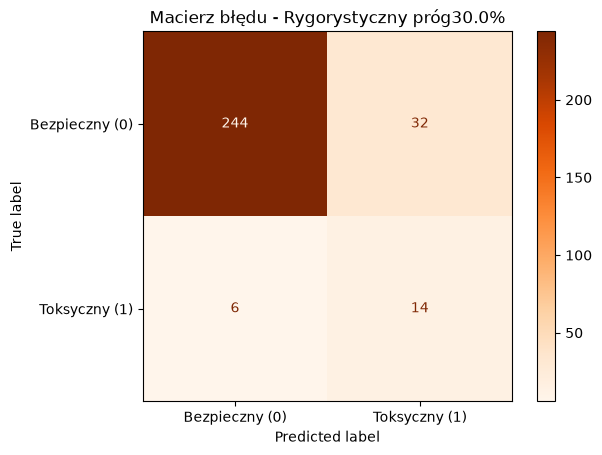

In [45]:
czyste_smiles = []
toksycznosc = []
X_lista = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

for index, row in df.iterrows():
    sml = row['smiles']
    tox_label = row['CT_TOX']
    mol = Chem.MolFromSmiles(sml)
    if mol is not None:
        czyste_smiles.append(mol)
        toksycznosc.append(tox_label)

        fp = morgan_gen.GetFingerprint(mol)
        X_lista.append(list(fp))
X = np.array(X_lista)
y = np.array(toksycznosc)
print("Rozpoczynam nauke modelu...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
print("Trening zakończony sukcesem")
prawdopodobienstwo = model.predict_proba(X_test)
szansa_na_toksycznosc = prawdopodobienstwo[:, 1] # Zostaw wszystkie wiersze ale wytnij tylko drugą kolumne. Wyciągam tylko szansę na toskyczność

nowy_prog=0.30
y_pred_ryg = (szansa_na_toksycznosc >= nowy_prog).astype(int) #Jesli toksycznosc wynosi 0.3 lub wiecej daje True. Funkcja astpye(int) zmienia to na twardą jedynkę, a poniżej 0.3 w zero.

cm = confusion_matrix(y_test, y_pred_ryg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bezpieczny (0)', 'Toksyczny (1)'])

disp.plot(cmap=plt.cm.Oranges)
plt.title(f"Macierz błędu - Rygorystyczny próg{nowy_prog*100}%")
plt.show()

Poprawiłem tutaj kod na próg na 50% jak jest to ustawione klasycznie i zobacz wyszedł ten sam wynik co w Day11 :)

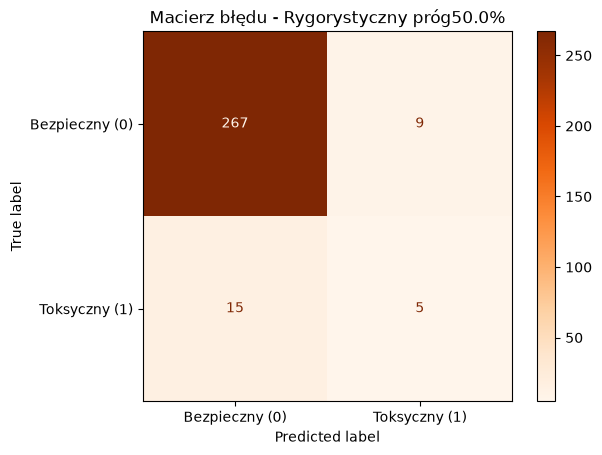

In [50]:
prawdopodobienstwo = model.predict_proba(X_test)
szansa_na_toksycznosc = prawdopodobienstwo[:, 1] # Zostaw wszystkie wiersze ale wytnij tylko drugą kolumne. Wyciągam tylko szansę na toskyczność

nowy_prog=0.50
y_pred_ryg = (szansa_na_toksycznosc >=nowy_prog).astype(int) #Jesli toksycznosc wynosi 0.3 lub wiecej daje True. Funkcja astpye(int) zmienia to na twardą jedynkę, a poniżej 0.3 w zero.

cm = confusion_matrix(y_test, y_pred_ryg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bezpieczny (0)', 'Toksyczny (1)'])

disp.plot(cmap=plt.cm.Oranges)
plt.title(f"Macierz błędu - Rygorystyczny próg{nowy_prog*100}%")
plt.show()

Poniżej zmieniłem próg na 10% żeby zobaczyć jak model zachowa sie w takim przypadku.

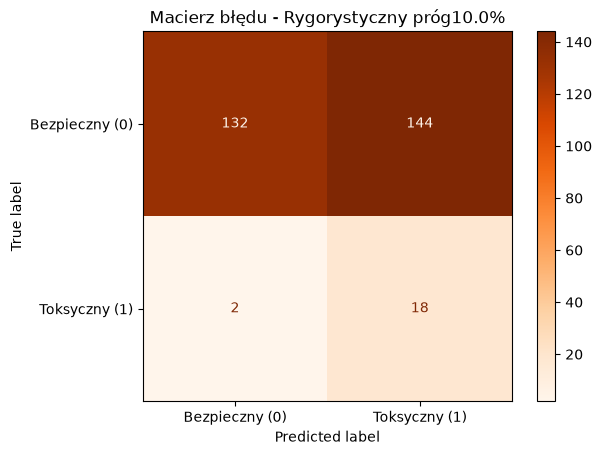

In [51]:
prawdopodobienstwo = model.predict_proba(X_test)
szansa_na_toksycznosc = prawdopodobienstwo[:, 1] # Zostaw wszystkie wiersze ale wytnij tylko drugą kolumne. Wyciągam tylko szansę na toskyczność

nowy_prog=0.10
y_pred_ryg = (szansa_na_toksycznosc >=nowy_prog).astype(int) #Jesli toksycznosc wynosi 0.3 lub wiecej daje True. Funkcja astpye(int) zmienia to na twardą jedynkę, a poniżej 0.3 w zero.

cm = confusion_matrix(y_test, y_pred_ryg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bezpieczny (0)', 'Toksyczny (1)'])

disp.plot(cmap=plt.cm.Oranges)
plt.title(f"Macierz błędu - Rygorystyczny próg{nowy_prog*100}%")
plt.show()

[00:48:37] Explicit valence for atom # 0 N, 4, is greater than permitted
[00:48:38] Can't kekulize mol.  Unkekulized atoms: 9
[00:48:39] Can't kekulize mol.  Unkekulized atoms: 4
[00:48:39] Can't kekulize mol.  Unkekulized atoms: 4


Rozpoczynam nauke modelu...
Trening zakończony sukcesem


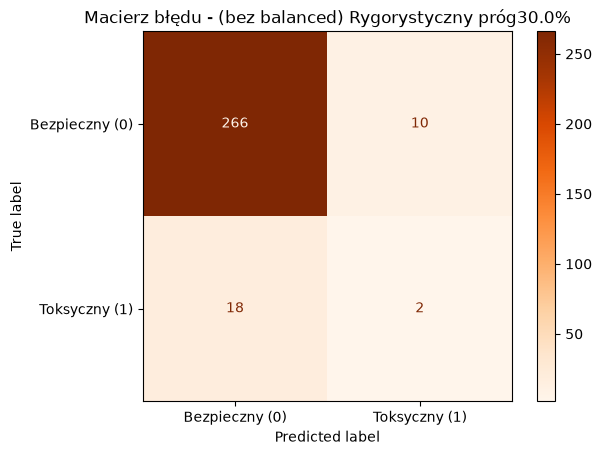

In [52]:
czyste_smiles = []
toksycznosc = []
X_lista = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

for index, row in df.iterrows():
    sml = row['smiles']
    tox_label = row['CT_TOX']
    mol = Chem.MolFromSmiles(sml)
    if mol is not None:
        czyste_smiles.append(mol)
        toksycznosc.append(tox_label)

        fp = morgan_gen.GetFingerprint(mol)
        X_lista.append(list(fp))
X = np.array(X_lista)
y = np.array(toksycznosc)
print("Rozpoczynam nauke modelu...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Trening zakończony sukcesem")
prawdopodobienstwo = model.predict_proba(X_test)
szansa_na_toksycznosc = prawdopodobienstwo[:, 1] # Zostaw wszystkie wiersze ale wytnij tylko drugą kolumne. Wyciągam tylko szansę na toskyczność

nowy_prog=0.30
y_pred_ryg = (szansa_na_toksycznosc >= nowy_prog).astype(int) #Jesli toksycznosc wynosi 0.3 lub wiecej daje True. Funkcja astpye(int) zmienia to na twardą jedynkę, a poniżej 0.3 w zero.

cm = confusion_matrix(y_test, y_pred_ryg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bezpieczny (0)', 'Toksyczny (1)'])

disp.plot(cmap=plt.cm.Oranges)
plt.title(f"Macierz błędu - (bez balanced) Rygorystyczny próg{nowy_prog*100}%")
plt.show()

Sprawdze ile w bazie testowych realnie jest związków toksycznych oraz bezpiecznych z tego wyciągne wnioski.

In [53]:
import numpy as np

# Liczba bezpiecznych i toksycznych w y_test
liczba_bezpiecznych = np.sum(y_test == 0)
liczba_toksycznych = np.sum(y_test == 1)

print(f"Liczba bezpiecznych (0) w y_test: {liczba_bezpiecznych}")
print(f"Liczba toksycznych (1) w y_test: {liczba_toksycznych}")
print(f"Łączna liczba cząsteczek w teście: {len(y_test)}")

Liczba bezpiecznych (0) w y_test: 276
Liczba toksycznych (1) w y_test: 20
Łączna liczba cząsteczek w teście: 296


Wioski:
1. Pierwszorzędnie opisze wpływ funkcji class_weight=balanced. Porównywać będziemy ze sobą wykres 1 oraz 4. W Wykresie bez tej funkcji (wykres 4) model jest skrajnie ostrożny. Wykrył zaledwie 2 toksyny z 20 przpuszczając jako bezpieczne 18 toksyn (nieładnie). Włączenie funkcji (wykres 1) zmusił algorytm do zwracania uwagi na rzadkie trucizny. Wykrył on 14 cząsteczek toksycznych a 6 toksyn uznał za bezpieczne. Funkcja balanced oznaczyła o 22 więcej cząsteczek jako trucizna a tak na prawde były to cząsteczki bezpieczne. Oba wykresy miały ustawiony próg 0.3. Balanced wykrywa więcej trucizn, aczkolwiek więcej bezpiecznych związków trafia do kategorii toksycznej według modelu (lek mógł być wykluczony przez model)
2. Drugorzędnie porównam wykres z progiem 50% (wykres 2) z wykresem z progiem 10% (wykres 3). Wykres 2 przepuszcza 15 toksyn co jest nieakcpetowalnym wynikiem. Wykres 3 natomiast działa jak absolutne sito wyłapał mi 18 na 20 toksyn co jest na prawde stosunkowo do mojego kodowania dobrym wynikiem ale zakwalifikował jako toksyny zawrotne 144 bezpieczne cząsteczki.
3. Zdecydowanie widać że złotym środkiem w miare moich możliwości kodowania i rozumowania jest wykres 1 w którym użyta została funkcja balanced oraz próg wynosił 30%. Złapano 14 trucizn przy liczbie "fałszywych alarmów" wynoszącą 32 cząsteczki. Nie paraliżuje on całego zbioru bezpiecznych substancji